In [92]:
import pandas as pd

from plastic_neuron import PlasticNeuron
from abstract_neuron import AbstractNeuron
from neuron_utils import NeuronUtils
from neuron_plots import NeuronPlots
import matplotlib.pyplot as plt
from neuron import h
import numpy as np

# Subthreshold LTP without the electric field

The neuron has 10 synapses. All synapses receive potentiating inputs of 100 Hz for 1000 ms, starting at 1000 ms and ending at 2000 ms.

The test stimulus (a single stimulus to all synapses) is provided at 100 ms (before LTP protocol) and at 2500 ms (after LTP protocol).

Goal: find such a conductance that after providing a test stimulus to all synapses, it would not elicit APs before the LTP protocol but would elicit APs after LTP protocol for 50% of the cases without the electric field.

In [93]:
test_stimulus_1 = 100
test_stimulus_2 = 2500

In [94]:
idxs = np.arange(0, 20)
conductances = [ format(i, ".6f") for i in np.arange(0.00005, 0.0001 + 0.000005, 0.000005) ]

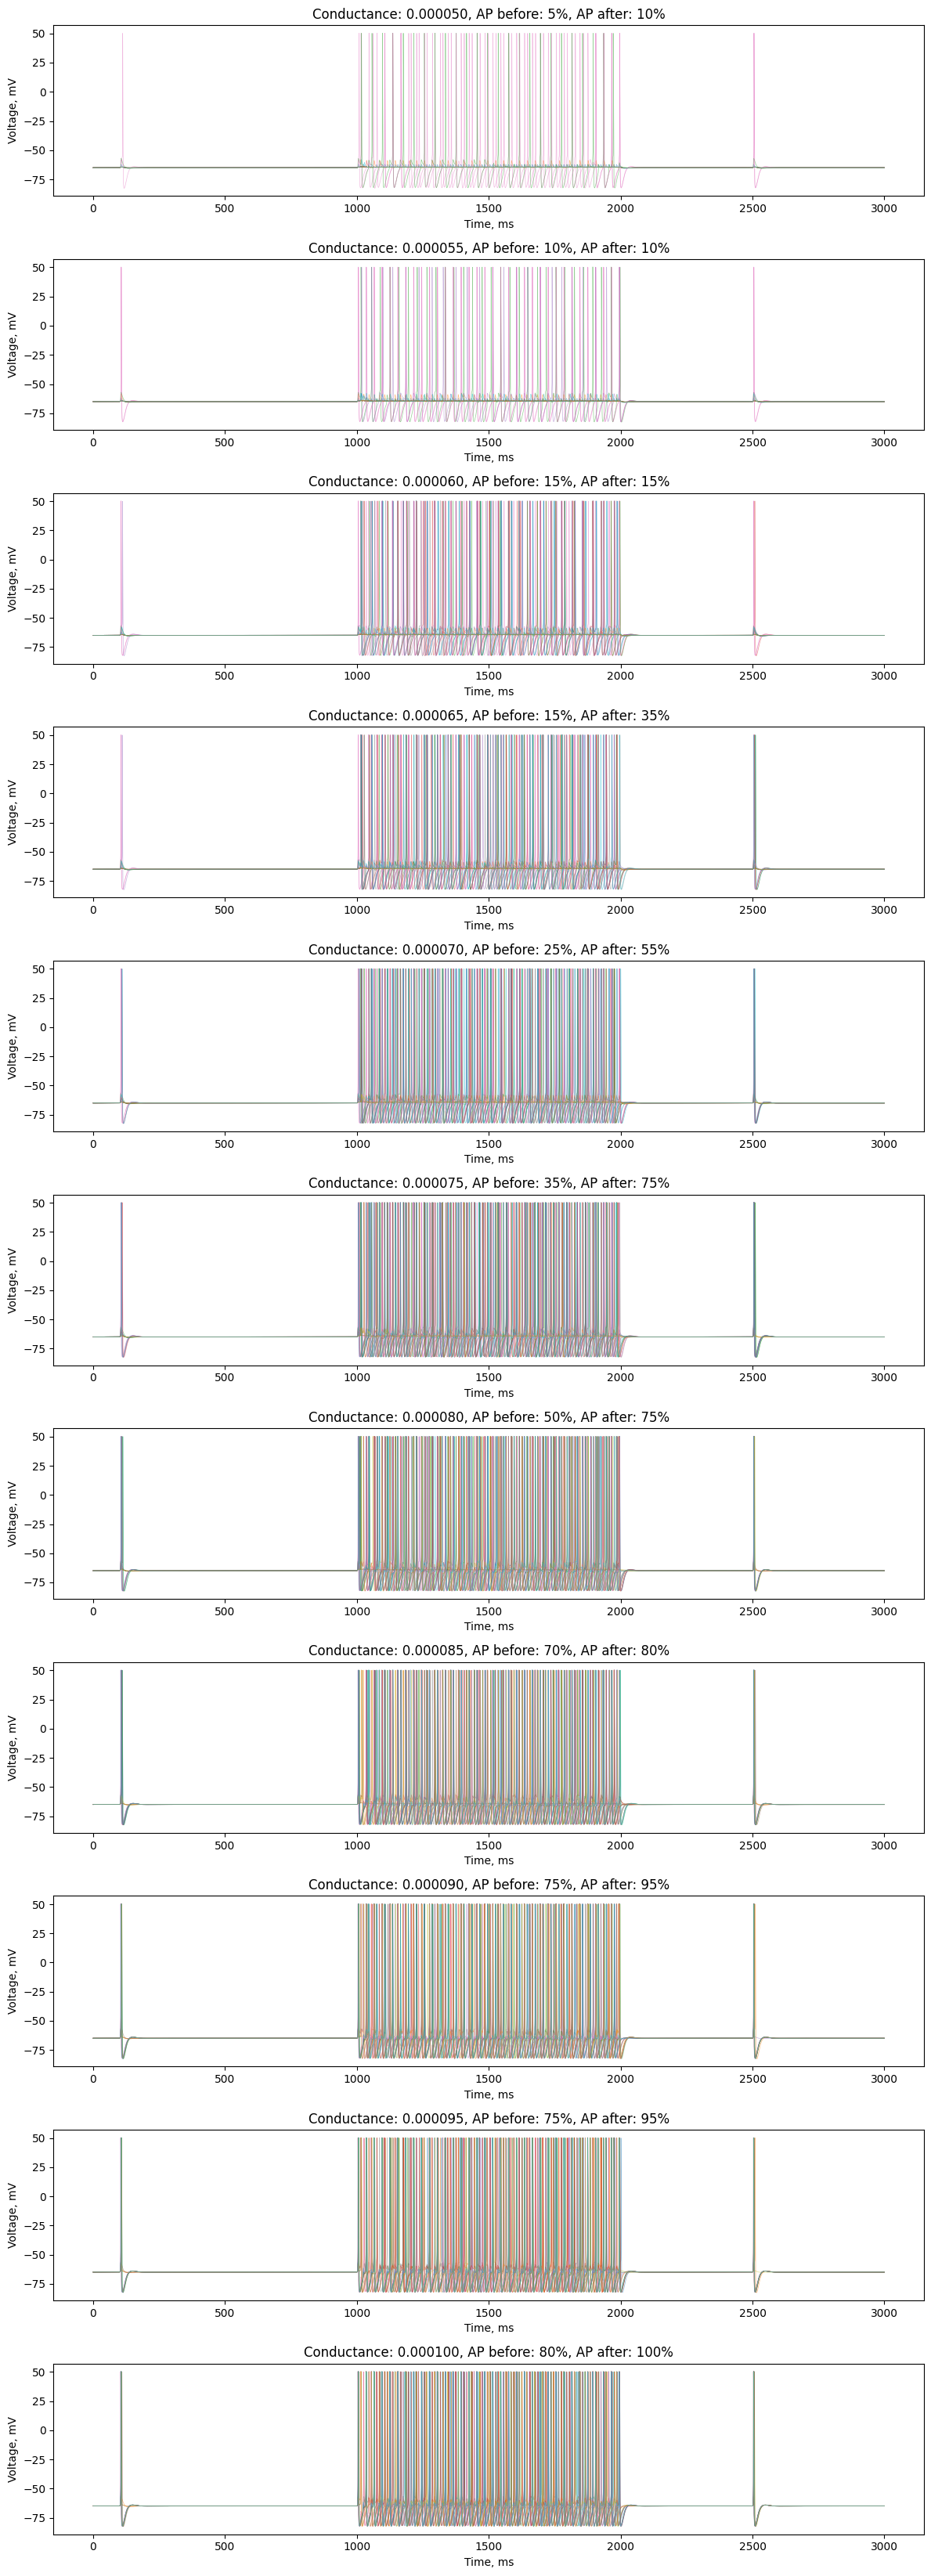

In [95]:
fig, axs = plt.subplots(nrows = len(conductances), ncols = 1, figsize = (12, len(conductances) * 3))

for conductance, ax in zip(conductances, axs):
    spike_before = 0
    spike_after = 0
    for idx in idxs:
        voltage = pd.read_csv(f"output/temporal-interference/conductance_ltp/{idx}/{conductance}/voltage.csv")
        
        ax.plot(
            voltage.Time,
            voltage.Voltage,
            linewidth = 0.5,
            alpha = 0.5
        )

        epsp_1 = np.array(voltage.Voltage[np.where(np.logical_and(voltage.Time > test_stimulus_1 - 50, voltage.Time < test_stimulus_1 + 150))[0]].tolist())
        epsp_2 = np.array(voltage.Voltage[np.where(np.logical_and(voltage.Time > test_stimulus_2 - 50, voltage.Time < test_stimulus_2 + 150))[0]].tolist())
        
        spike_before += np.any(epsp_1 > -20)
        spike_after += np.any(epsp_2 > -20)

    ax.set_xlabel("Time, ms")
    ax.set_ylabel("Voltage, mV")
    ax.set_title(f"Conductance: {conductance}, AP before: {round(spike_before / len(idxs) * 100)}%, AP after: {round(spike_after / len(idxs) * 100)}%")

fig.tight_layout()
plt.show()

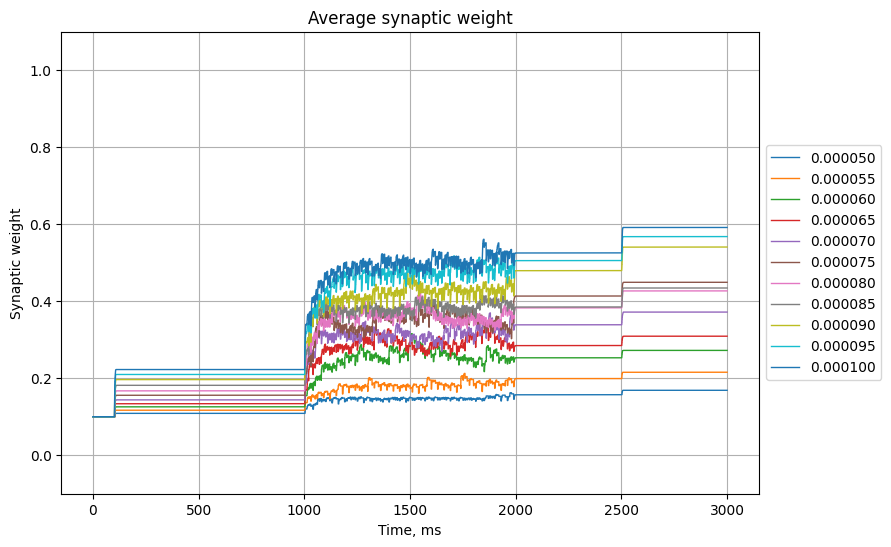

In [111]:
plt.figure(figsize = (9, 6))

for conductance in conductances:
    weights = []
    time = []
    for idx in idxs:
        synapse_weights = pd.read_csv(f"output/temporal-interference/conductance_ltp/{idx}/{conductance}/synapse_weights.csv", index_col = 0)
        synapses = [ f"Synapse{i}" for i in range(0, 10) ]
        
        idx_weights = np.array([ synapse_weights[synapse] for synapse in synapses ])
        weights.append(idx_weights)
        time = synapse_weights.Time
    
    weights = np.concatenate(weights)
    plt.plot(time, weights.mean(axis = 0), label = conductance, linewidth = 1)

plt.ylim(-0.1, 1.1)
plt.title("Average synaptic weight")
plt.xlabel("Time, ms")
plt.ylabel("Synaptic weight")
plt.legend(loc = "center left", bbox_to_anchor = (1, 0.5))
plt.grid()

plt.show()

Unhandled case!
Has AP before: True
Has AP after: False
Unhandled case!
Has AP before: True
Has AP after: False


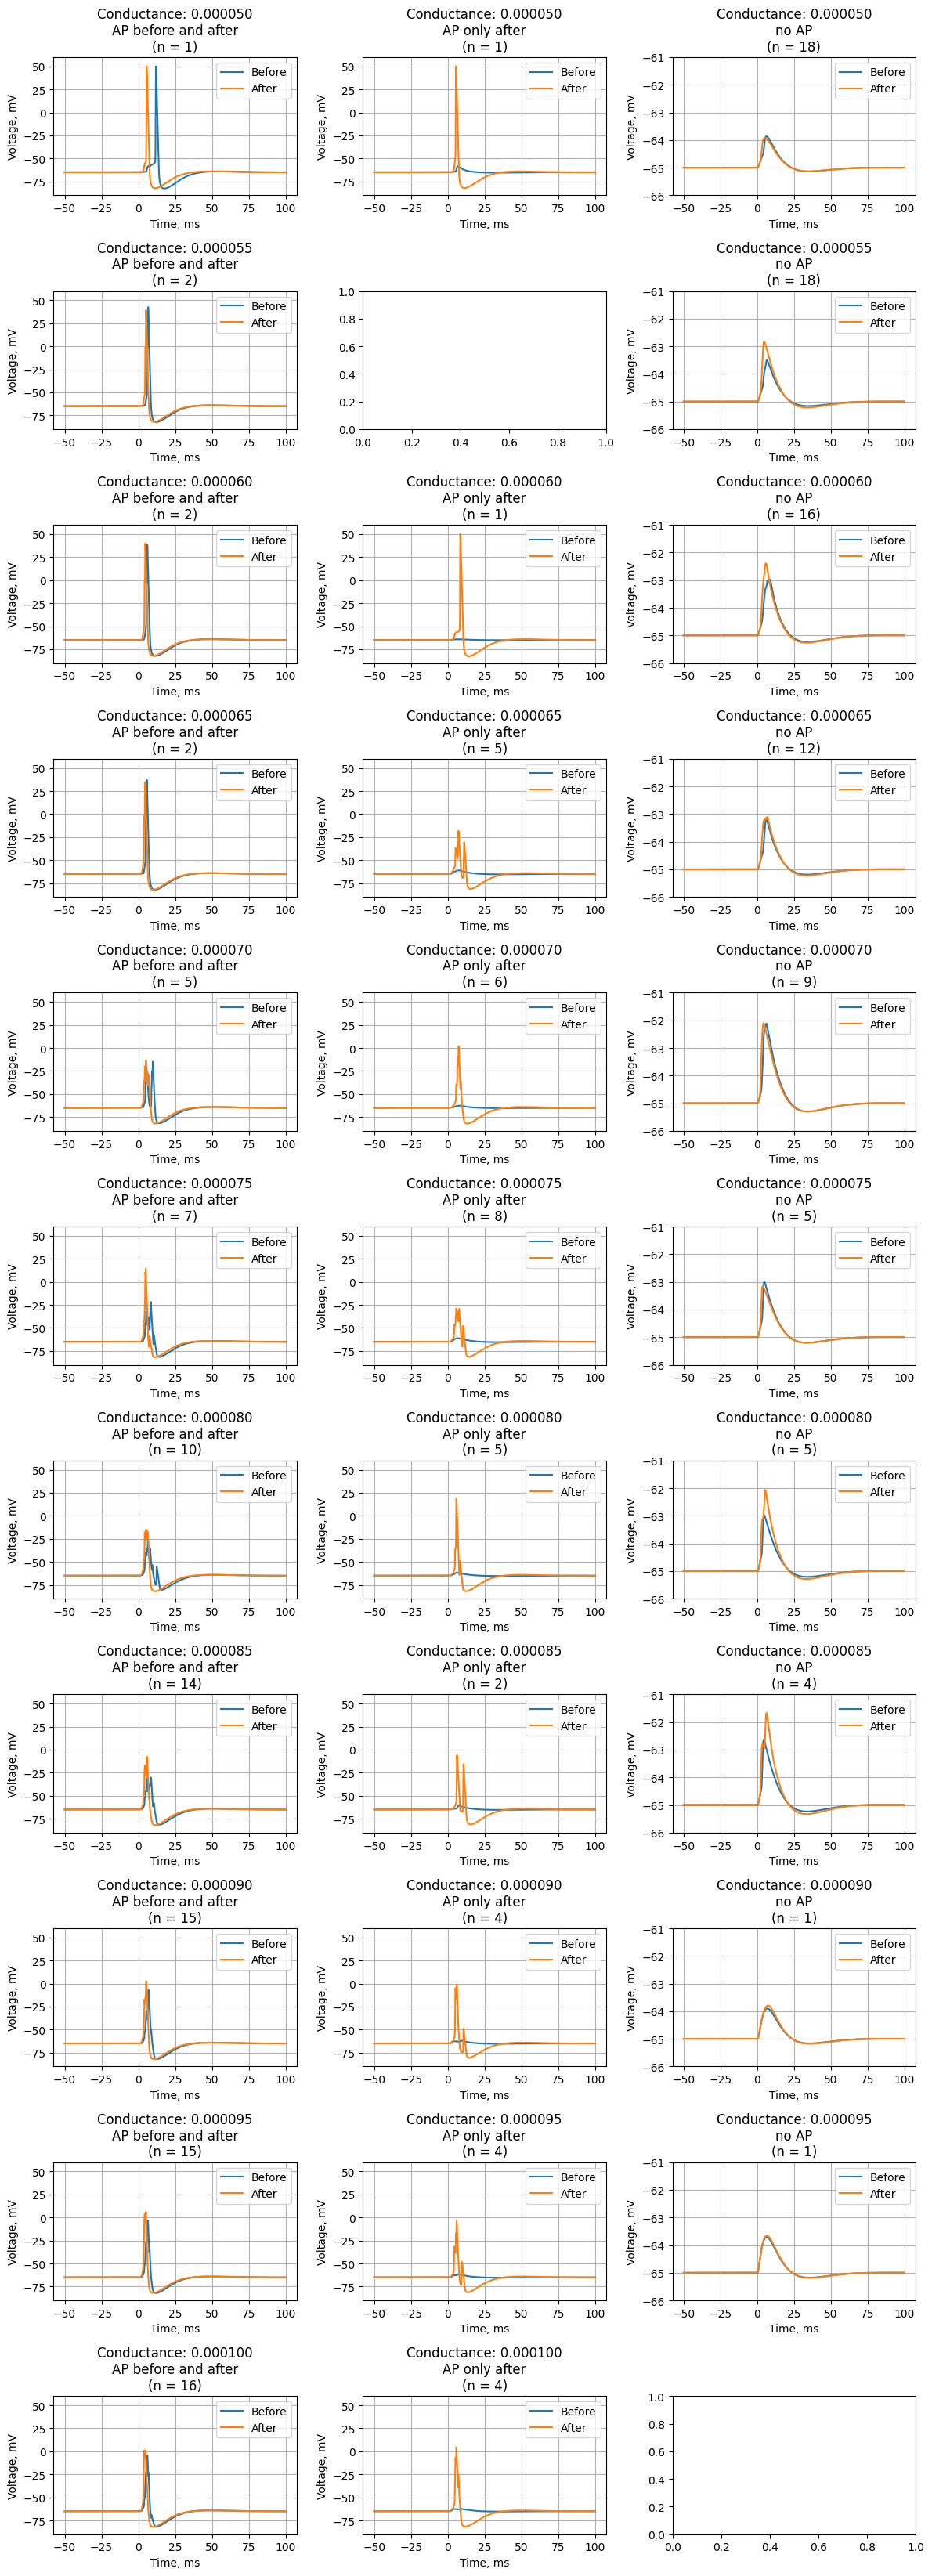

In [108]:
time_before = 50
time_after = 100

fig, axs = plt.subplots(nrows = len(conductances), ncols = 3, figsize = (12, len(conductances) * 3))

for i, conductance in enumerate(conductances):    
    epsp_before_has_ap_both = []
    epsp_after_has_ap_both = []
    
    epsp_before_has_ap_after = []
    epsp_after_has_ap_after = []
    
    epsp_before_no_ap = []
    epsp_after_no_ap = []
    
    for idx in idxs:
        voltage = pd.read_csv(f"output/temporal-interference/conductance_ltp/{idx}/{conductance}/voltage.csv")

        epsp_before = np.array(voltage.Voltage[np.where(np.logical_and(voltage.Time > test_stimulus_1 - time_before, voltage.Time < test_stimulus_1 + time_after))[0]].tolist())
        epsp_after = np.array(voltage.Voltage[np.where(np.logical_and(voltage.Time > test_stimulus_2 - time_before, voltage.Time < test_stimulus_2 + time_after))[0]].tolist())
        
        has_ap_before = np.any(epsp_before > -20)
        has_ap_after = np.any(epsp_after > -20)
        
        if has_ap_before and has_ap_after:
            epsp_before_has_ap_both.append(epsp_before)
            epsp_after_has_ap_both.append(epsp_after)
            continue
        
        if not has_ap_before and has_ap_after:
            epsp_before_has_ap_after.append(epsp_before)
            epsp_after_has_ap_after.append(epsp_after)
            continue
        
        if not has_ap_before and not has_ap_after:
            epsp_before_no_ap.append(epsp_before)
            epsp_after_no_ap.append(epsp_after)
            continue
        
        print("Unhandled case!")   
        print(f"Has AP before: {has_ap_before}")
        print(f"Has AP after: {has_ap_after}")

    time = np.arange(-time_before, time_after + 0.025, 0.025)

    if len(epsp_before_has_ap_both) > 0:
        count = len(epsp_before_has_ap_both)
        epsp_before_has_ap_both = np.stack(epsp_before_has_ap_both).mean(axis = 0)
        epsp_after_has_ap_both = np.stack(epsp_after_has_ap_both).mean(axis = 0)

        ax = axs[i][0]
        ax.set_ylabel("Voltage, mV")
        ax.set_xlabel("Time, ms")
        ax.plot(
            time[:len(epsp_before_has_ap_both)],
            epsp_before_has_ap_both,
            label = "Before"
        )
        ax.plot(
            time[:len(epsp_after_has_ap_both)],
            epsp_after_has_ap_both,
            label = "After"
        )

        ax.set_title(f"Conductance: {conductance}\nAP before and after\n(n = {count})")
        ax.legend(loc = "upper right")
        ax.set_ylim(-90, 60)
        ax.grid()
    
    if len(epsp_before_has_ap_after) > 0:
        count = len(epsp_before_has_ap_after)
        epsp_before_has_ap_after = np.stack(epsp_before_has_ap_after).mean(axis = 0)
        epsp_after_has_ap_after = np.stack(epsp_after_has_ap_after).mean(axis = 0)

        ax = axs[i][1]
        ax.set_ylabel("Voltage, mV")
        ax.set_xlabel("Time, ms")
        ax.plot(
            time[:len(epsp_before_has_ap_after)],
            epsp_before_has_ap_after,
            label = "Before"
        )
        ax.plot(
            time[:len(epsp_after_has_ap_after)],
            epsp_after_has_ap_after,
            label = "After"
        )

        ax.set_title(f"Conductance: {conductance}\nAP only after\n(n = {count})")
        ax.legend(loc = "upper right")
        ax.set_ylim(-90, 60)
        ax.grid()
    
    if len(epsp_before_no_ap) > 0:
        count = len(epsp_before_no_ap)
        epsp_before_no_ap = np.stack(epsp_before_no_ap).mean(axis = 0)
        epsp_after_no_ap = np.stack(epsp_after_no_ap).mean(axis = 0)

        ax = axs[i][2]
        ax.set_ylabel("Voltage, mV")
        ax.set_xlabel("Time, ms")
        ax.plot(
            time[:len(epsp_before_no_ap)],
            epsp_before_no_ap,
            label = "Before"
        )
        ax.plot(
            time[:len(epsp_after_no_ap)],
            epsp_after_no_ap,
            label = "After"
        )

        ax.set_title(f"Conductance: {conductance}\nno AP\n(n = {count})")
        ax.legend(loc = "upper right")
        ax.set_ylim(-66, -61)
        ax.grid()

fig.tight_layout()
plt.show()